In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import numpy as np
import seaborn as sns


In [ ]:
df=pd.read_csv("churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.drop("customerID",axis=1,inplace=True)
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df["TotalCharges"].unique()

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [ ]:
# df["TotalCharges"]=df["TotalCharges"].map({" ":np.nan})


In [ ]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [7]:
df[df["TotalCharges"].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [11]:
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [13]:
np.max(df["tenure"])

np.int64(72)

([<matplotlib.axis.XTick at 0x160beff9550>,
 [Text(0, 0, '0'),
  Text(6, 0, '6'),
  Text(12, 0, '12'),
  Text(18, 0, '18'),
  Text(24, 0, '24'),
  Text(30, 0, '30'),
  Text(36, 0, '36'),
  Text(42, 0, '42'),
  Text(48, 0, '48'),
  Text(54, 0, '54'),
  Text(60, 0, '60'),
  Text(66, 0, '66'),
  Text(72, 0, '72')])

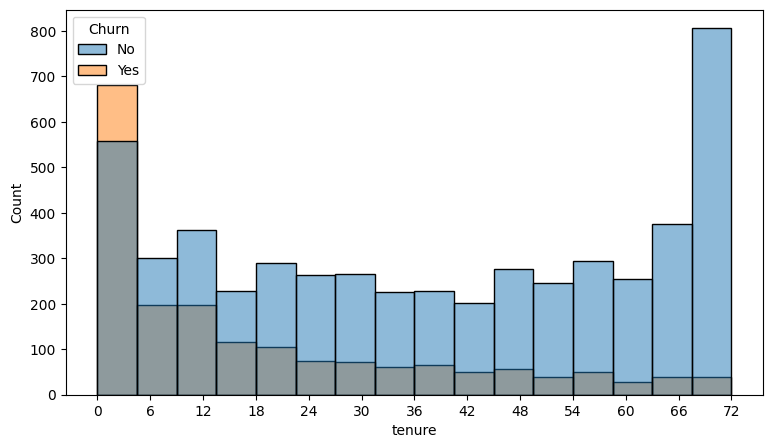

In [14]:
plt.figure(figsize=(9,5))
sns.histplot(data=df,x="tenure",hue="Churn")
plt.xticks(np.arange(0,73,6))

In [15]:
df[["StreamingMovies","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV"]]=df[["StreamingMovies","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV"]].replace({"No internet service":"No","No phone service":"No"})

In [16]:
object_cols=df.select_dtypes(include="object").columns
for c in object_cols:
    print(c)
    print(df[c].unique())
    print("\n\n\n\n\n\n --------------- \n\n\n\n\n\n\n")

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str






 --------------- 







Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str






 --------------- 







Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







MultipleLines
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str






 --------------- 







OnlineSecurity
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







OnlineBackup
<StringArray>
['Yes', 'No']
Length: 2, dtype: str






 --------------- 







DeviceProtection
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







TechSupport
<StringArray>
['No', 'Yes']
Length: 2, dtype: str






 --------------- 







StreamingTV
<StringArray>
['No', 'Yes']
Leng

C:\Users\Access\AppData\Local\Temp\ipykernel_4412\1521692485.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols=df.select_dtypes(include="object").columns


In [17]:
yes_no_cols=["Partner","Dependents","PhoneService","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","PaperlessBilling","Churn"]

for c in yes_no_cols:
    
    df[c]=df[c].replace({"Yes":1,"No":0}).astype("int64")
    
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [18]:
df["gender"]=df["gender"].replace({
    "Female":1,
    "Male":0
}).astype("int64")
df["gender"].dtypes

dtype('int64')

In [19]:
df=pd.get_dummies(data=df,columns=["InternetService","Contract","PaymentMethod"],dtype=int)


In [20]:
df.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No             

In [21]:
df.sample(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3942,0,0,0,0,1,1,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
4196,1,0,1,1,70,1,1,0,0,0,...,0,0,1,0,0,1,0,0,0,1
238,1,1,0,0,11,1,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
3158,0,0,1,0,18,1,0,0,0,1,...,1,0,0,1,0,0,0,0,0,1


In [22]:
cols_scale=["tenure","MonthlyCharges","TotalCharges"]

from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

df[cols_scale]=scaler.fit_transform(df[cols_scale])
df[cols_scale]

,tenure,MonthlyCharges,TotalCharges
0,0.013889,0.115423,0.001275
1,0.472222,0.385075,0.215867
2,0.027778,0.354229,0.010310
3,0.625000,0.239303,0.210241
4,0.027778,0.521891,0.015330
...,...,...,...
7038,0.333333,0.662189,0.227521
7039,1.000000,0.845274,0.847461
7040,0.152778,0.112935,0.037809
7041,0.055556,0.558706,0.033210


In [23]:
y=df["Churn"]
x=df.drop("Churn",axis=1)




In [24]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)


In [25]:
type(x_train)

pandas.DataFrame

In [26]:
x_train.shape

(5634, 26)

In [27]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [28]:
model=keras.Sequential([
    keras.layers.Dense(20,input_shape=(26,),activation="relu"),
    keras.layers.Dense(64,input_shape=(26,),activation="relu"),
    keras.layers.Dense(32,input_shape=(26,),activation="relu"),
    keras.layers.Dense(16,input_shape=(26,),activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")
])

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

c:\Users\Access\Desktop\tensor\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.fit(x_train,y_train,epochs=20)

Epoch 1/20


177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7728 - loss: 0.4602
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7975 - loss: 0.4279
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7975 - loss: 0.4243
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7987 - loss: 0.4206
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7994 - loss: 0.4198
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8028 - loss: 0.4151
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8035 - loss: 0.4128
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8049 - loss: 0.4115
Epoch 9/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8062 - loss: 0.4088
Epoch 10/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8074 - loss: 0.4088
Epoch 11/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8074 - loss: 0.4065
Epoch 12/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy

In [30]:
model.evaluate(x_test,y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8048 - loss: 0.4254


[0.42541906237602234, 0.8048261404037476]

In [31]:
predictions=model.predict(x_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [32]:
y_predicted=[]

for p in predictions:
    
    if p >= 0.5:
        y_predicted.append(1)
    else:
        y_predicted.append(0)

In [33]:
from sklearn.metrics import confusion_matrix,classification_report

print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1061
           1       0.64      0.48      0.55       348

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.79      0.80      0.80      1409



In [34]:
cm=confusion_matrix(y_test,y_predicted)

print(confusion_matrix(y_test,y_predicted))

[[966  95]
 [180 168]]


<Axes: >

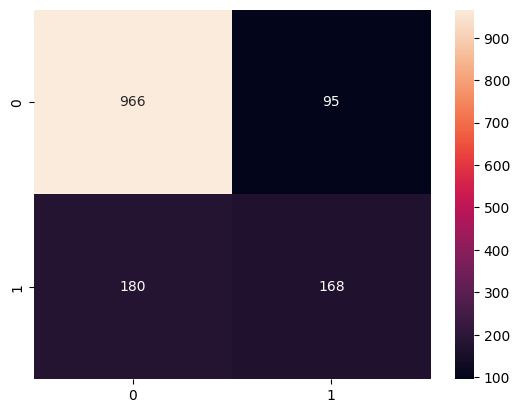

In [35]:
sns.heatmap(cm,annot=True,fmt="d")

## Precision for 0

In [36]:
# how this model can predict "0" correctly

round(966/(180+966),2)

0.84

## Precision for 1

In [ ]:
# how can this model predict  "1" correctly

round(229/(229+137),2)

0.63